# Geometry Probe: Forget vs Retain Analysis

This notebook compares metric changes for prompts labeled as `forget` vs `retain`.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RUN_DIR = Path('unlearn_results/dea/run_default/all_prompts')

per_edit = pd.read_csv(RUN_DIR / 'forget_retain_per_edit_deltas.csv')
prompt_features = pd.read_csv(RUN_DIR / 'prompt_features.csv')
set_edit_summary = pd.read_csv(RUN_DIR / 'forget_retain_set_edit_summary.csv')
prompt_edit_summary = pd.read_csv(RUN_DIR / 'forget_retain_prompt_edit_summary.csv')

print('per_edit rows:', len(per_edit))
print('prompt_features rows:', len(prompt_features))
display(set_edit_summary.head())

per_edit rows: 4800
prompt_features rows: 400


,set_label,edit_type,n_rows,mean_delta_abnormality,mean_abs_delta_abnormality,median_abs_delta_abnormality,mean_delta_entropy,mean_delta_gap,mean_delta_refusal
0,forget,entity_swap,60,-0.139565,1.141736,1.095550,0.299796,-0.268660,-0.383333
1,forget,paraphrase_lite,60,0.505460,0.698870,0.538097,0.420645,-1.263147,-0.175000
2,forget,relation_swap,60,0.192753,0.909194,0.820104,0.551272,-0.505785,-0.333333
3,forget,template_edit,60,0.195447,0.892037,0.633208,0.273356,-0.922540,-0.250000
4,retain,entity_swap,1140,0.777105,0.914842,0.614191,0.329467,-1.710017,0.000439


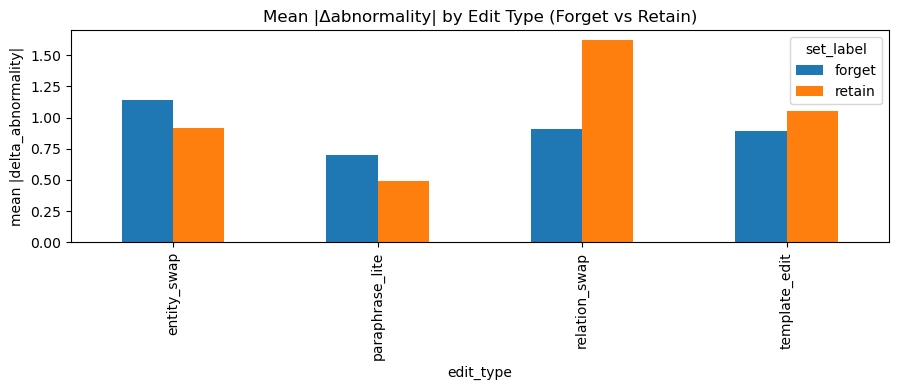

In [2]:
# 1) Mean |delta abnormality| by edit type and set label
pivot_abs = set_edit_summary.pivot(index='edit_type', columns='set_label', values='mean_abs_delta_abnormality').fillna(0)
ax = pivot_abs.plot(kind='bar', figsize=(9,4))
ax.set_title('Mean |Δabnormality| by Edit Type (Forget vs Retain)')
ax.set_ylabel('mean |delta_abnormality|')
ax.set_xlabel('edit_type')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1740584/4073050791.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)


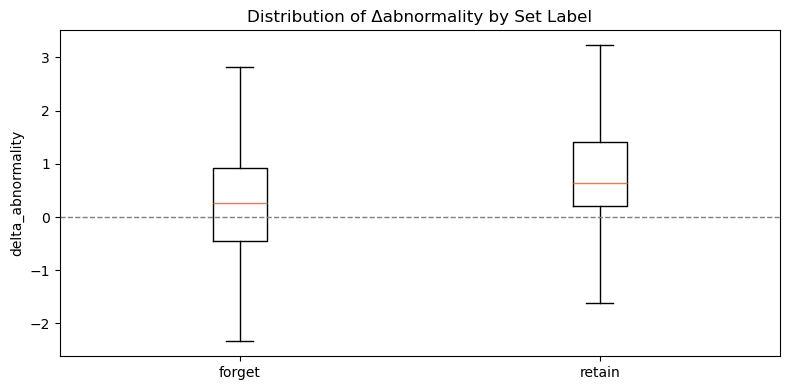

In [3]:
# 2) Distribution of delta_abnormality by set label
labels = ['forget', 'retain']
data = [per_edit.loc[per_edit['set_label']==lb, 'delta_abnormality'].dropna() for lb in labels]
plt.figure(figsize=(8,4))
plt.boxplot(data, labels=labels, showfliers=False)
plt.axhline(0.0, color='gray', linestyle='--', linewidth=1)
plt.title('Distribution of Δabnormality by Set Label')
plt.ylabel('delta_abnormality')
plt.tight_layout()
plt.show()

,set_label,mean,median,count
0,forget,0.808333,0.833333,20
1,retain,0.778509,0.791667,380


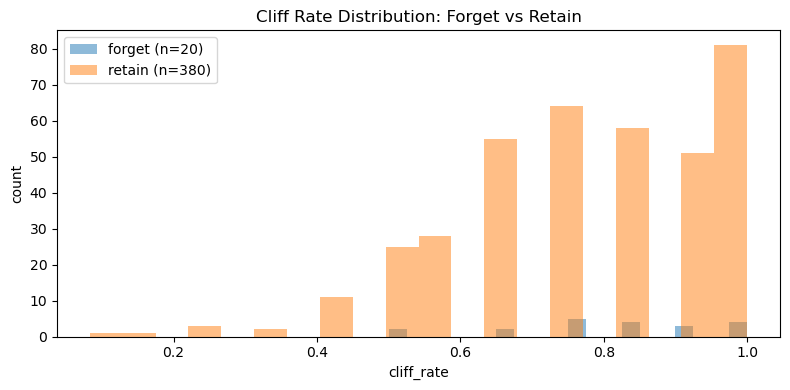

In [4]:
# 3) Cliff-rate comparison at prompt level
tmp = prompt_features.groupby('set_label')['cliff_rate'].agg(['mean','median','count']).reset_index()
display(tmp)

plt.figure(figsize=(8,4))
for lb in ['forget', 'retain']:
    vals = prompt_features.loc[prompt_features['set_label']==lb, 'cliff_rate'].dropna()
    plt.hist(vals, bins=20, alpha=0.5, label=f'{lb} (n={len(vals)})')
plt.title('Cliff Rate Distribution: Forget vs Retain')
plt.xlabel('cliff_rate')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# 4) Per-prompt mean Δabnormality across edit types
pivot_prompt = prompt_edit_summary.pivot_table(
    index='seed_prompt',
    columns='edit_type',
    values='mean_delta_abnormality',
    aggfunc='mean'
)
meta = prompt_edit_summary[['seed_prompt','set_label']].drop_duplicates().set_index('seed_prompt')
pivot_prompt = pivot_prompt.join(meta, how='left')

display(pivot_prompt.head())

,entity_swap,paraphrase_lite,relation_swap,template_edit,set_label
seed_prompt,,,,,
After how many days would unpaid balances incur a late payment penalty based on the contract between Avrbci Ltd and Wnzatj SAS?,0.310750,0.092160,0.721254,0.430309,retain
After how many days would unpaid balances incur a late payment penalty based on the contract between Clsvfw AG and Mjlwxf NV?,0.650306,0.524312,1.360434,1.111641,retain
After how many days would unpaid balances incur a late payment penalty based on the contract between Cqndue LLC and Ctvepy SAS?,0.435207,0.050521,1.242124,0.637046,retain
After how many days would unpaid balances incur a late payment penalty based on the contract between Jzrcws SA and Dmimyu GmbH?,0.644470,0.111161,0.858519,0.389241,retain
After how many days would unpaid balances incur a late payment penalty based on the contract between Jzrcws SA and Lasnoj SAS?,0.300408,-0.228975,0.513676,0.031699,retain


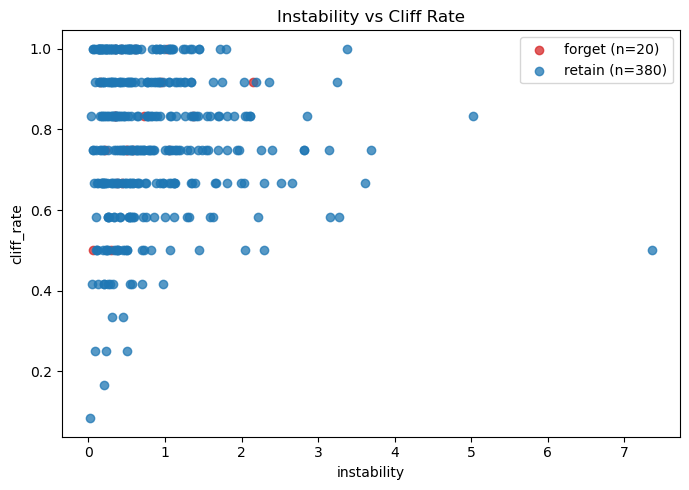

In [6]:
# 5) Scatter: instability vs cliff_rate colored by set
colors = {'forget':'tab:red', 'retain':'tab:blue', 'unknown':'tab:gray'}
plt.figure(figsize=(7,5))
for lb, sub in prompt_features.groupby('set_label'):
    plt.scatter(sub['instability'], sub['cliff_rate'], label=f'{lb} (n={len(sub)})', alpha=0.75, c=colors.get(lb,'tab:gray'))
plt.title('Instability vs Cliff Rate')
plt.xlabel('instability')
plt.ylabel('cliff_rate')
plt.legend()
plt.tight_layout()
plt.show()